# **Project : Product Return Prediction**

## Introduction
In this project, we focus on understanding the reasons behind product returns and predict whether a product will be returned. Our primary goal is to provide actionable insights to retailers rather than achieving the maximum model accuracy. By identifying patterns and factors that leads to returns, we aim to help businesses to reduce return rates and associated costs.

## Problem Statement
To Predict the likelihood of a product being returned based on various features such as product category, price and customer demographics. The goal of this project is to provide insights into the factors that contribute to product returns, enabling reatilers to make informed decisions and improve their return policies and customer experience.

## Business Problem
In the retail industry, product returns are a significant challenge, impacting profitablity and customer satisfaction. Understanding the reasons behind returns can help retailers improve their products, services and customer experience.     

## Mapping the Real-World Problem to a Machine Learning Problem
**It is a machine learning binary classification problem where we predict whether a order will be returned or not. By analyzing various order features, its aim to help businesses reduce return rates and improve customer satisfaction.**

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable

### Dispaly Settings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')


### Data Ingestion and Exploration

In [3]:
path = Path.cwd()
paths = path.parent.joinpath('data', 'raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)

['.gitkeep', 'Global Superstore.xls']


In [4]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()

dict_keys(['Orders', 'Returns', 'People'])

In [5]:
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1),
    return_df.tail(1),
    people_df.tail(1))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [6]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)

'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [7]:
# remove whitespaces from column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip()

In [8]:
# Lets lower case all column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.lower()


In [9]:
# lets check the data types of the columns
order_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row id          51290 non-null  int64         
 1   order id        51290 non-null  object        
 2   order date      51290 non-null  datetime64[ns]
 3   ship date       51290 non-null  datetime64[ns]
 4   ship mode       51290 non-null  object        
 5   customer id     51290 non-null  object        
 6   customer name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product id      51290 non-null  object        
 15  ca

In [10]:
return_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [11]:
people_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   person  13 non-null     object
 1   region  13 non-null     object
dtypes: object(2)
memory usage: 340.0+ bytes


**Dataset Summary**

**The Global Superstore dataset contains three sheets: Orders, Returns and People.**
    
- **The Orders sheet contains information about customer orders, including order ID, customer ID, demographic details ,product details and sales data.**    
- **The Returns sheet contains information about returned orders, including order ID and market details.**    
- **The people sheet contains information about customers, including customer name and demographic details.**
    
**The data spans a robust four-year period from 2011 to 2015 . This dataset contains a vast array of order-related information, offering insights into retail operations across 147 countries.**


Brief description of columns:

- **Order Information**

    - **Order ID** – Unique identifier for each order.

    - **Order Date** – Date when the order was placed.

    - **Ship Date** – Date when the order was shipped.

    - **Ship Mode** – Shipping method (e.g., Standard Class, Second Class, First Class, Same Day).

- **Customer Information**

    - **Customer ID** – Unique identifier for each customer.

    - **Customer Name** – Name of the customer.

    - **Segment** – Customer segment (Consumer, Corporate, Home Office).

    - **Country** – Country where the customer is located.

    - **City / State / Region** – Geographic details of the customer.

- **Product Information**

    - **Product ID** – Unique identifier for each product.

    - **Category** – Broad product category (Furniture, Office Supplies, Technology).

    - **Sub-Category** – More specific product type (e.g., Chairs, Phones, Binders).

    - **Product Name** – Name/description of the product.

- **Sales & Profit Metrics**

    - **Sales** – Revenue generated from the order.

    - **Quantity** – Number of units sold.

    - **Discount** – Discount applied to the order.

    - **Profit** – Profit earned from the order after costs.

- **Geographic & Managerial**

    - **Region** – Region of the world (e.g., Asia, Europe, US).

    - **Postal Code** – Postal/ZIP code of the customer.

    - **Market** – Market grouping (e.g., APAC, EMEA).

- **Returns (separate sheet)**

    - **Returned** – Indicates whether an order was returned.

## **Number Formatting and Category Consistency**

In [51]:
order_df.columns = order_df.columns.str.replace(' ', '_')
print(order_df.columns)
return_df.columns = return_df.columns.str.replace(' ', '_')
print(return_df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'order_year',
       'order_month', 'order_week', 'order_dayofyear', 'order_yearmonth'],
      dtype='object')
Index(['returned', 'order_id', 'market'], dtype='object')


In [52]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
dtype_df

,dtype,nunique,unique
row_id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order_id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order_date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship_date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship_mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer_id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer_name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


In [53]:
def highlight_zero_neg(val):
    if val == 0:
        return 'background-color: yellow; color: black'   # zero values highlighted in yellow
    elif val < 0:
        return 'background-color: red; color: white'    # negative values highlighted in red
    else:
        return ''  # no highlight for positive values

In [54]:
# Number Formatting and data description for numerical columns
df_desc = order_df.describe(exclude='object')
display(df_desc.style.applymap(highlight_zero_neg, subset = df_desc.select_dtypes(include='number').columns))


,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_cost,order_year,order_month,order_week,order_dayofyear,order_yearmonth
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,,nan,48
top,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,,nan,2014-12
freq,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,,nan,2153
mean,25645.500000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818,2012.777208,7.522636,30.675687,213.601852,nan
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000,2011.000000,1.000000,1.000000,1.000000,nan
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000,2012.000000,5.000000,20.000000,136.000000,nan
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000,2013.000000,8.000000,33.000000,228.000000,nan
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000,2014.000000,10.000000,44.000000,304.000000,nan
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000,2014.000000,12.000000,52.000000,366.000000,nan


**NOTEs**:
- **Discount**: The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.
- **Profit**: The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


In [55]:
order_df.describe(include='object')

,order_id,ship_mode,customer_id,customer_name,segment,city,state,country,market,region,product_id,category,sub-category,product_name,order_priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


### **Missing Value Analysis**

In [56]:
missing_df = order_df.stb.missing()
missing_df[missing_df['missing']!=0]

,missing,total,percent
postal_code,41296,51290,80.51472


In [57]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order_id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**

- **Lets explore return dataframe and transform return_df column to bool type and examine if market category is clean(no two or more names for same market, etc.)**

In [58]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df


In [59]:
# let's clean return_df and store as returns
returns = clean_return_df(return_df)
returns.head()

,returned,order_id,market
0,True,MX-2013-168137,LATAM
1,True,US-2011-165316,LATAM
2,True,ES-2013-1525878,EU
3,True,CA-2013-118311,US
4,True,ES-2011-1276768,EU


## **What are Overall Trends of **Sales and Profit**?**

#### **KPIs (Key Performance Indicators)**

In [62]:
kpis = {
    'total_sales' : order_df['sales'].sum().round(2),
    'total_profit' : order_df['profit'].sum().round(2),
    'profit_margin': (order_df['profit'].sum() / order_df['sales'].sum()) * 100,
    'total_orders': order_df['order_id'].nunique(),
    'avg_order_value': order_df['sales'].sum() / order_df['order_id'].nunique(),
    'total_quantity_sold': order_df['quantity'].sum(),
    'total_customers': order_df['customer_id'].nunique()
    }

kpi_df = pd.DataFrame.from_dict([kpis])
kpi_df

,total_sales,total_profit,profit_margin,total_orders,avg_order_value,total_quantity_sold,total_customers
0,12642501.91,1467457.29,11.607333,25035,504.993086,178312,1590


##### **Seasonal Sales Trend**

##### **1. What data do you have?**

To detect seasonality, the dataset should include at least:

- **A date or time column**: This is essential for identifying seasonal patterns. The date column should cover multiple years to capture recurring trends.
- **Inventory related columns**: Columns such as sales, profit, or stock levels are crucial for analyzing seasonal fluctuations in order and return.
- **Possibly Product or category columns**: These can help in understanding if certain products or categories exhibit seasonal trends.


Will analyze daily, weekly, monthly sales trends across years to identify seasonal patterns and peak sales periods. And, visualize which seasonal trend is more clearer and relevant . Total sum or mean of sales seems appropriate for good summary.

In [63]:
order_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'order_year',
       'order_month', 'order_week', 'order_dayofyear', 'order_yearmonth'],
      dtype='object')

In [65]:
# Requirement gatheing of data for seasonal analysis
print(f"Order Date data type: {order_df['order_date'].dtype}")
print(order_df['order_date'].head(1))


Order Date data type: datetime64[ns]
0   2012-07-31
Name: order_date, dtype: datetime64[ns]


In [66]:
# Create new dimensions from order date column like year, month, week, dayofyear, etc.
order_df['order_year'] = order_df['order_date'].dt.year
order_df['order_month'] = order_df['order_date'].dt.month
order_df['order_week'] = order_df['order_date'].dt.isocalendar().week
order_df['order_dayofyear'] = order_df['order_date'].dt.dayofyear   
print("Newly created date dimensions:", '\n', order_df[['order_date','order_year', 'order_month', 'order_week', 'order_dayofyear']].head(4))


Newly created date dimensions: 
   order_date  order_year  order_month  order_week  order_dayofyear
0 2012-07-31        2012            7          31              213
1 2013-02-05        2013            2           6               36
2 2013-10-17        2013           10          42              290
3 2013-01-28        2013            1           5               28


order_year,2011,2012,2013,2014,mean
order_dayofyear,,,,,
1,808.56300,0.0000,9369.15300,3614.03450,3447.937625
2,314.22000,10006.6647,11613.89560,4169.51614,6526.074110
3,4503.53720,3453.3043,5790.96900,11327.62200,6268.858125
4,2808.87024,2617.8439,16266.57344,4705.27370,6599.640320
5,3662.31000,5662.2250,5795.99950,426.66000,3886.798625


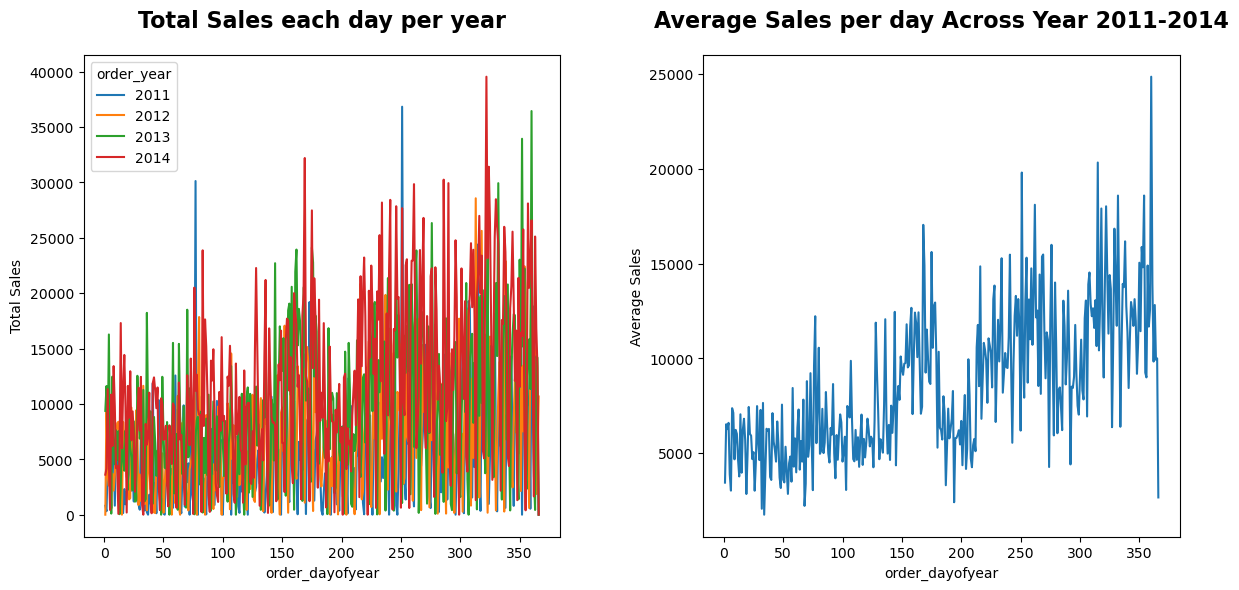

In [76]:
# seasonal trend of sales by day of year.
day_df = order_df.groupby(['order_year', 'order_dayofyear'])['sales'].sum().unstack('order_year').fillna(0)

# mean of sales for each day across all years
day_df['mean'] = day_df.mean(axis=1)

# look at day_df data
display(day_df.head())
print()

# plot the total and average number of orders each day across years
fig, ax = plt.subplots(1,2, figsize=(12,6))
day_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales each day per year', fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel('Total Sales')

day_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Sales per day Across Year 2011-2014', fontsize=16, fontweight='bold',y=1.04)
ax[1].set_ylabel('Average Sales')

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


order_year,2011,2012,2013,2014,mean
order_week,,,,,
1,25827.28344,38829.40230,77404.65144,79441.96422,55375.825350
2,27169.67248,35688.28800,43816.68000,48901.77510,38894.103895
3,21799.13634,29299.88110,34755.11334,64301.23464,37538.841355
4,15337.02860,37752.55224,35454.70040,58539.48958,36770.942705
5,20268.44130,24496.07314,51991.55730,46149.44600,35726.379435


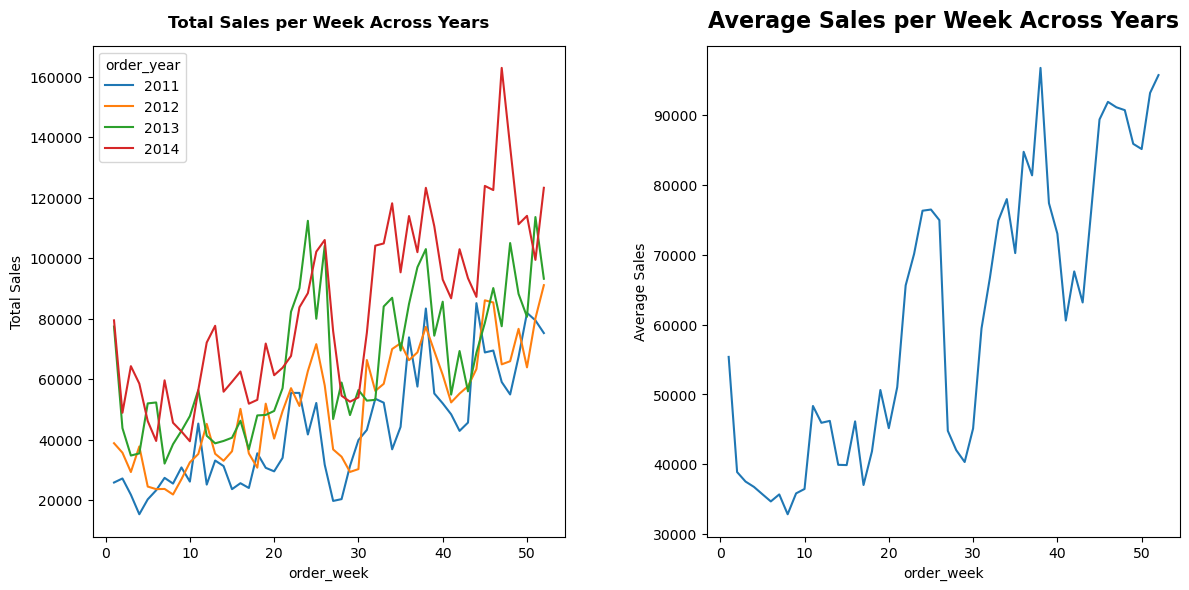

In [77]:
# seasonal trend of sales per week across years
week_df = order_df.groupby(['order_year', 'order_week'])['sales'].sum().unstack('order_year').fillna(0)

# mean of sales for each week across years
week_df['mean'] = week_df.mean(axis=1)

# look at the data
display(week_df.head())
print()
# plot the total quantity of each week across years and aveage quantity of each week across years as well
fig, ax = plt.subplots(1,2, figsize=(12,6))
week_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales per Week Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Sales')

week_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Sales per Week Across Years', fontsize=16, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Sales')

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


order_year,2011,2012,2013,2014,mean
order_month,,,,,
1,98898.48886,135780.72024,199185.90738,241268.55566,168783.418035
2,91152.15698,100510.21698,167239.65040,184837.35556,135934.844980
3,145729.36736,163076.77116,198594.03012,263100.77262,192625.235315
4,116915.76418,161052.26952,177821.31684,242771.86130,174640.302960
5,146747.83610,208364.89124,260498.56470,288401.04614,226003.084545


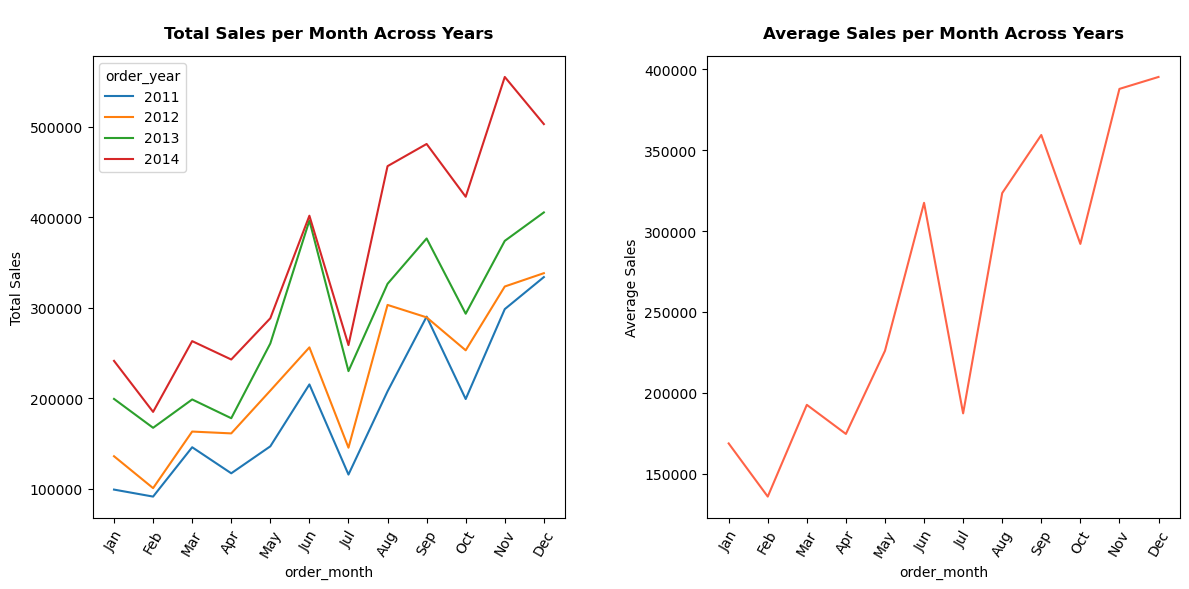

In [75]:
# seasonal trend of sales per month across years
month_df = order_df.groupby(['order_year', 'order_month'])['sales'].sum().unstack('order_year').fillna(0)

# mean of a product for each week across years
month_df['mean'] = month_df.mean(axis=1)

# look at the data
display(month_df.head())
# plot the total quantity of each month across years and aveage quantity of each month across years as well
fig, ax = plt.subplots(1, 2, figsize=(12,6))
month_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Sales')
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

month_df.iloc[:,-1].plot(ax=ax[1], color='tomato')
ax[1].set_title('\nAverage Sales per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Sales')
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add label and layouts
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


category         Furniture  Office Supplies     Technology
order_month                                               
1             57141.671450     55558.843900   56082.902685
2             46339.951400     38376.089325   51218.804255
3             63722.785950     56925.139150   71977.310215
4             52802.512700     56900.563475   64937.226785
5             70172.154325     69954.476900   85876.453320
6            102816.525950     93195.323375  121417.339085
7             56777.055075     58733.516525   71834.887580
8             98304.562525    100631.991600  124521.737205
9            123668.007750    106732.781800  128944.238040
10            95563.840575     75195.426375  121286.829620
11           125679.266725    117226.115525  144913.953130
12           134730.212150    117337.288425  143127.692600



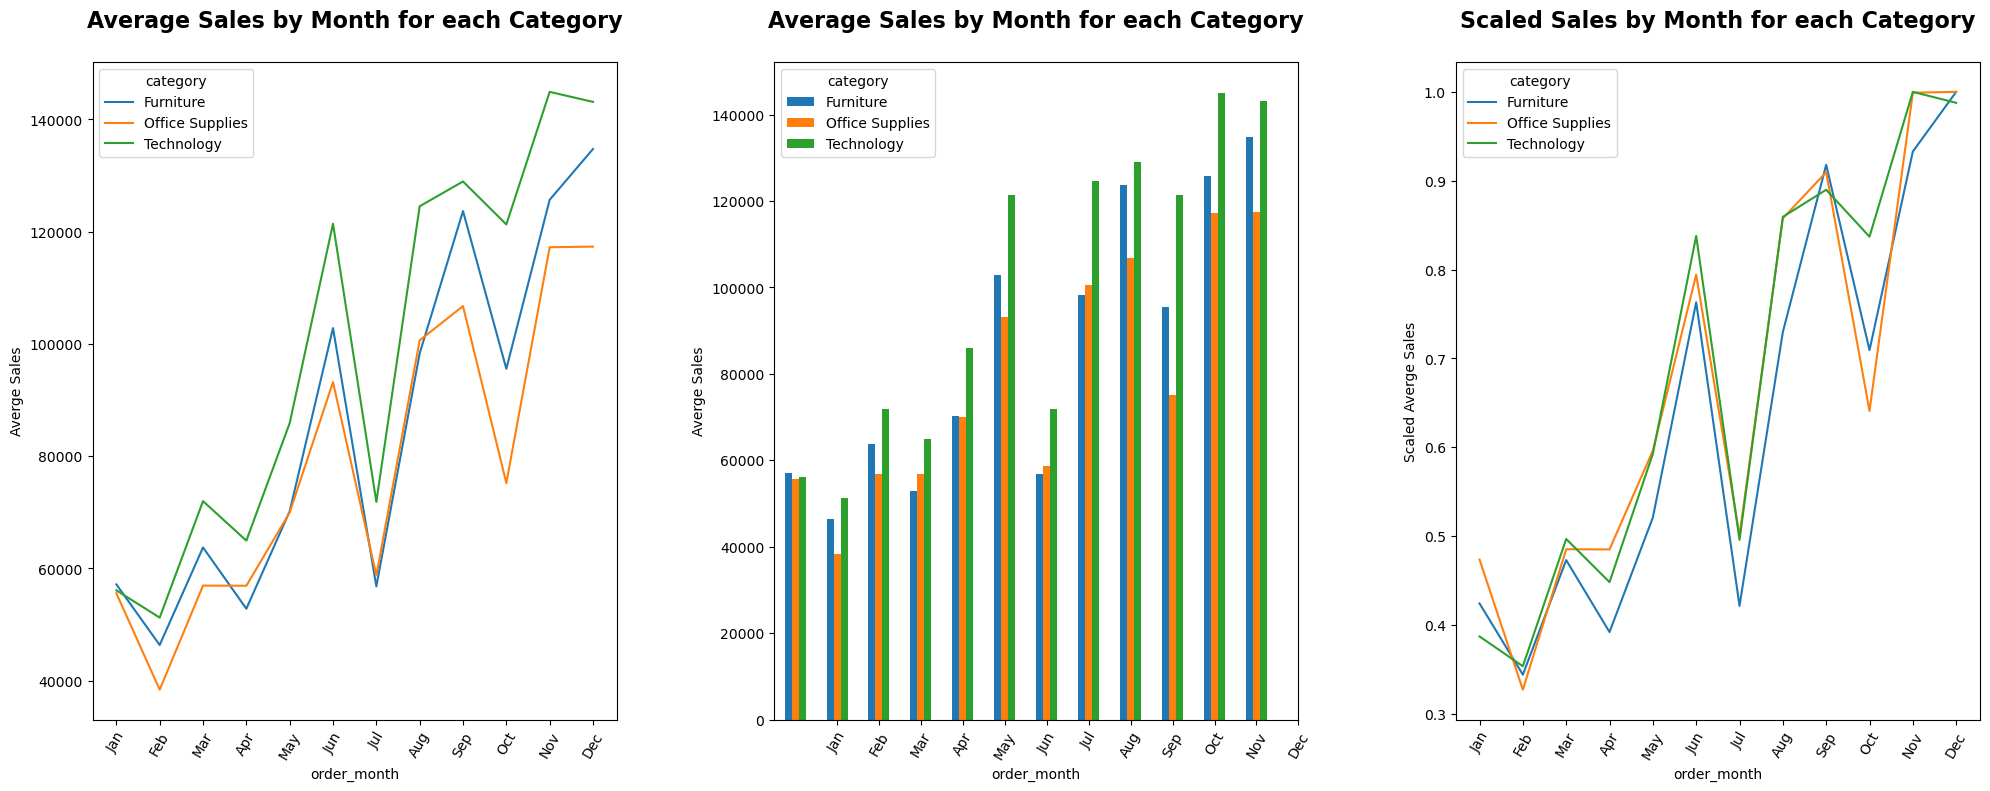

In [90]:
category_df = order_df.groupby(['order_month', 'order_year', 'category'])['sales'].sum().unstack('order_year').mean(axis=1).unstack('category')
print(category_df, end='\n\n')

# Lets normalize by max of order so we can compare seasonality across the product
scaled_df = category_df.apply(lambda col: col/col.max())

# visualize the average order by month for each category and scaled average order by month for each category
fig, ax = plt.subplots(1, 3, figsize=(20,8))
category_df.plot(ax=ax[0])
ax[0].set_title("Average Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel("Averge Sales")
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

category_df.plot(kind='bar',ax=ax[1])
ax[1].set_title("Average Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[1].set_ylabel("Averge Sales")
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)


scaled_df.plot(ax=ax[2])
ax[2].set_title("Scaled Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[2].set_ylabel("Scaled Averge Sales")
ax[2].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


#### **Sales by Region & Country**

**Sales by Region**

,sales,profit
region,,
Central,2822302.52,311403.98
South,1600907.04,140355.77
North,1248165.60,194597.95
Oceania,1100184.61,120089.11
Southeast Asia,884423.17,17852.33


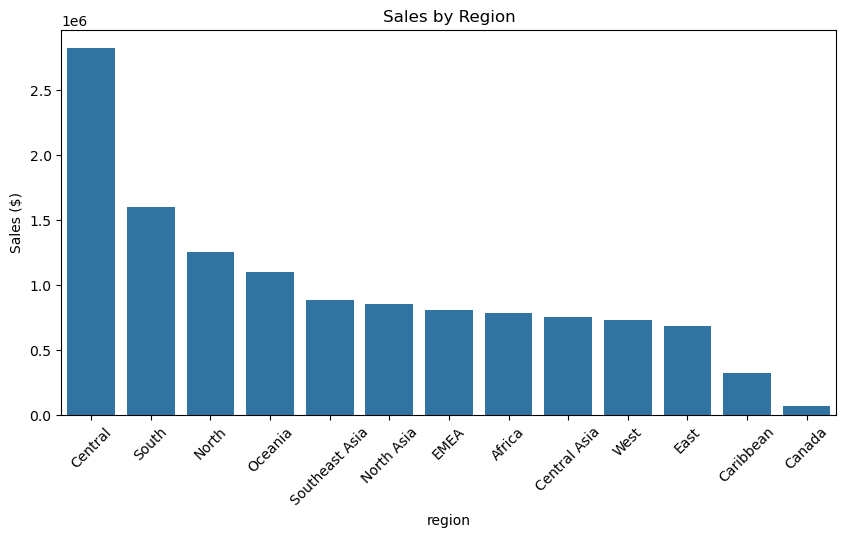

In [101]:
region_sales = order_df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
display(region_sales.round(2).head())
print()
# visualize the trend
plt.figure(figsize=(10,5))
sns.barplot(data=region_sales.reset_index(), x="region", y="sales")
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.ylabel("Sales ($)")
plt.show()


**Sales by Country**

In [96]:
country_sales = order_df.groupby("country")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
display(country_sales.round(2).head(10))
print()


,sales,profit
country,,
United States,2297200.86,286397.02
Australia,925235.85,103907.43
France,858931.08,109029.00
China,700562.02,150683.08
Germany,628840.03,107322.82
Mexico,622590.62,102818.10
India,589650.10,129071.84
United Kingdom,528576.30,111900.15
Indonesia,404887.50,15608.68


#### **Sales by Segment**

In [104]:
segment_sales = order_df.groupby("segment")[["sales","profit"]].sum()
display(segment_sales.round(2))


,sales,profit
segment,,
Consumer,6507949.42,749239.78
Corporate,3824697.52,441208.33
Home Office,2309854.97,277009.18


#### **Sales by Category & Sub-Category**

,sales,profit
sub-category,,
Phones,1706824.14,216717.01
Copiers,1509436.27,258567.55
Chairs,1501681.76,140396.27
Bookcases,1466572.24,161924.42
Storage,1127085.86,108461.49


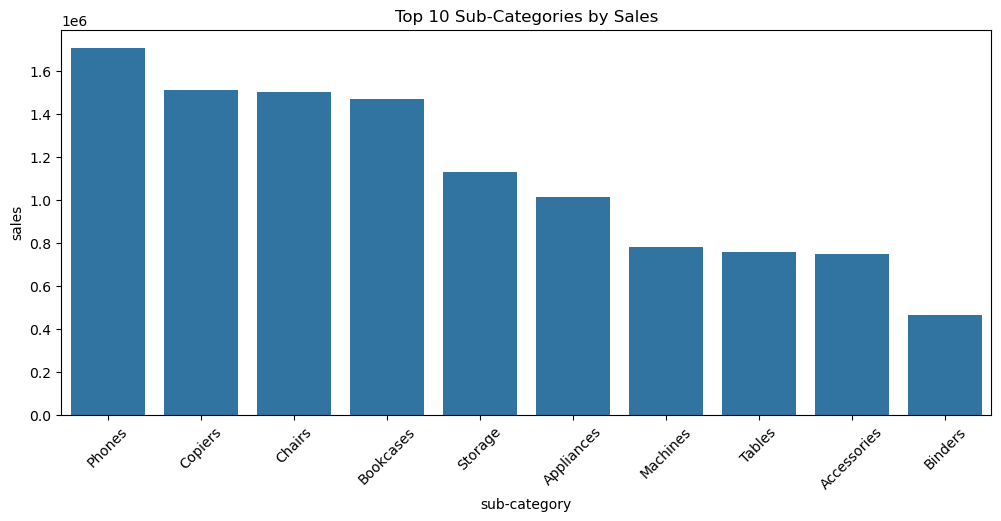

In [107]:
category_sales = order_df.groupby("category")[["sales", "profit"]].sum()
subcategory_sales = order_df.groupby("sub-category")[["sales", "profit"]].sum().sort_values("sales", ascending=False)

display(subcategory_sales.head().round(2))
print()
# visualize top 10 sub-categories by sales
plt.figure(figsize=(12,5))
sns.barplot(data=subcategory_sales.reset_index().head(10), x="sub-category", y="sales")
plt.title("Top 10 Sub-Categories by Sales")
plt.xticks(rotation=45)
plt.show()



#### **Product-Level Analysis**

In [110]:
order_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'order_year',
       'order_month', 'order_week', 'order_dayofyear', 'order_yearmonth'],
      dtype='object')

**Top-selling products**

In [111]:
top_products = order_df.groupby("product_name")[["sales","profit"]].sum().sort_values("sales", ascending=False)
top_products.head()


,sales,profit
product_name,,
"Apple Smart Phone, Full Size",86935.7786,5921.5786
"Cisco Smart Phone, Full Size",76441.5306,17238.5206
"Motorola Smart Phone, Full Size",73156.3030,17027.1130
"Nokia Smart Phone, Full Size",71904.5555,9938.1955
Canon imageCLASS 2200 Advanced Copier,61599.8240,25199.9280


**Most profitable products**

In [112]:
top_profit = order_df.groupby("product_name")[["profit"]].sum().sort_values("profit", ascending=False)
top_profit.head()


,profit
product_name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
"Cisco Smart Phone, Full Size",17238.5206
"Motorola Smart Phone, Full Size",17027.1130
"Hoover Stove, Red",11807.9690
"Sauder Classic Bookcase, Traditional",10672.0730


**Worst-loss products**

In [115]:
loss_products = order_df.groupby("product_name")[["profit"]].sum().sort_values("profit").head()
loss_products


,profit
product_name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
"Motorola Smart Phone, Cordless",-4447.0380
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
"Bevis Round Table, Adjustable Height",-3649.8940


#### **Shipping Mode Analysis**

,sales,profit
ship_mode,,
First Class,1830976.14,208104.68
Same Day,667201.98,76173.07
Second Class,2565671.68,292583.53
Standard Class,7578652.11,890596.02


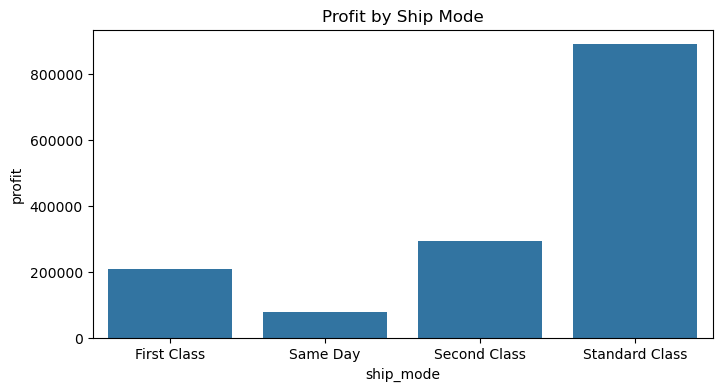

In [116]:
ship_sales = order_df.groupby("ship_mode")[["sales","profit"]].sum()
display(ship_sales.round(2))
print()
# visualize shipping mode analysis
plt.figure(figsize=(8,4))
sns.barplot(data=ship_sales.reset_index(), x="ship_mode", y="profit")
plt.title("Profit by Ship Mode")
plt.show()


### **Discount Impact on Profit**

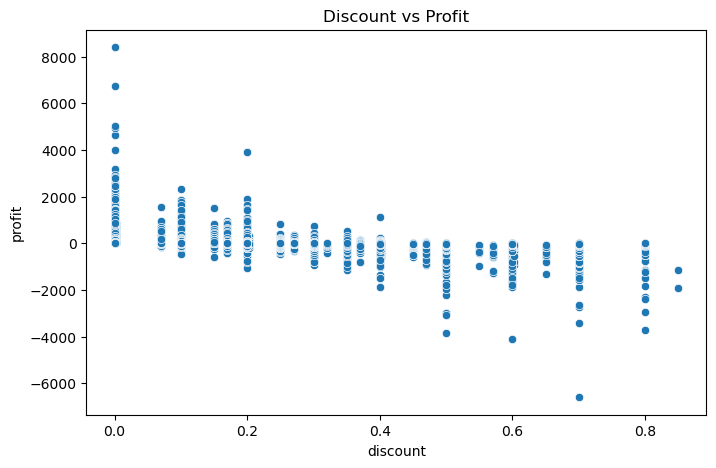

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=order_df, x="discount", y="profit")
plt.title("Discount vs Profit")
plt.show()
